# Homework 2 advanced analysis  

# Load Data and Packages

In [1]:
library(Seurat)
library(MAST)
library(ggrepel)
library(R.utils)
library(clusterProfiler)
library(org.Hs.eg.db)

Attaching SeuratObject

Attaching sp

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs

In [3]:
su3_1 <- readRDS("./hw1.rds")

# Differentially Expressed Genes

## Look at cell type and corresponding cell count

In [7]:
table(su3_1@ active.ident) # need a space before active


      T.cells1.Placenta_VentoTormo.             MO.Placenta_VentoTormo. 
                               2530                                1115 
      T.cells2.Placenta_VentoTormo.     B.cell.Adult.Peripheral.Blood1. 
                                588                                 667 
Blood.NK.CD16..Placenta_VentoTormo. Macrophage.Adult.Peripheral.Blood4. 
                                384                                 154 
        Plasma.Placenta_VentoTormo. 
                                 24 

In [8]:
labels <- levels(su3_1@ active.ident) # Identities as a character vector

## Find markers

In [9]:
deg <- FindMarkers(su3_1, 
                   ident.1 = 'T.cells1.Placenta_VentoTormo.', # Compare between 1 and others, 1 vs 1, or 1 vs some, just like what we did in cluster analysis
                   ident.2 = 'T.cells2.Placenta_VentoTormo.', 
                   logfc.threshold = 0, # Defaults to 0.25; with 0, output all result
                   min.pct = 0, # minimum percentage of cells
                   test.use="MAST" # Works well for single cell data, but do trial and error
                  )

head(deg)


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!



,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AC044802.2,0,-0.03793469,0.001,0.651,0
AC103702.2,0,-0.10827770,0.001,0.648,0
ADAMTS1,0,-0.03264837,0.003,0.655,0
CCL4,0,-1.74420697,0.060,0.852,0
CCL4L2,0,-0.23288970,0.004,0.665,0
CCL5,0,-3.95205212,0.223,0.995,0


> Compared two t-cell types. Would be interesting to see what happens.

## Label and plot marker genes

In [10]:
sign_deg <- subset(deg, p_val_adj<0.05 & abs(avg_log2FC)>0.15)
degdf <- deg
degdf$sign <- ifelse(degdf$p_val_adj < 0.05 & abs(degdf$avg_log2FC) > 0.15,rownames(degdf),NA)
degdf$symbol <- rownames(degdf)

In [11]:
P.Value_t = 0.05
degdf$change = ifelse(degdf$p_val_adj < P.Value_t & degdf$avg_log2FC < -0.15,"down",
                      ifelse(degdf$p_val_adj < P.Value_t & degdf$avg_log2FC > 0.15,"up","stable"))
table(degdf$change)


  down stable     up 
   333   1533    134 

Warning message:
“Removed 1533 rows containing missing values (geom_label_repel).”
Warning message:
“ggrepel: 431 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


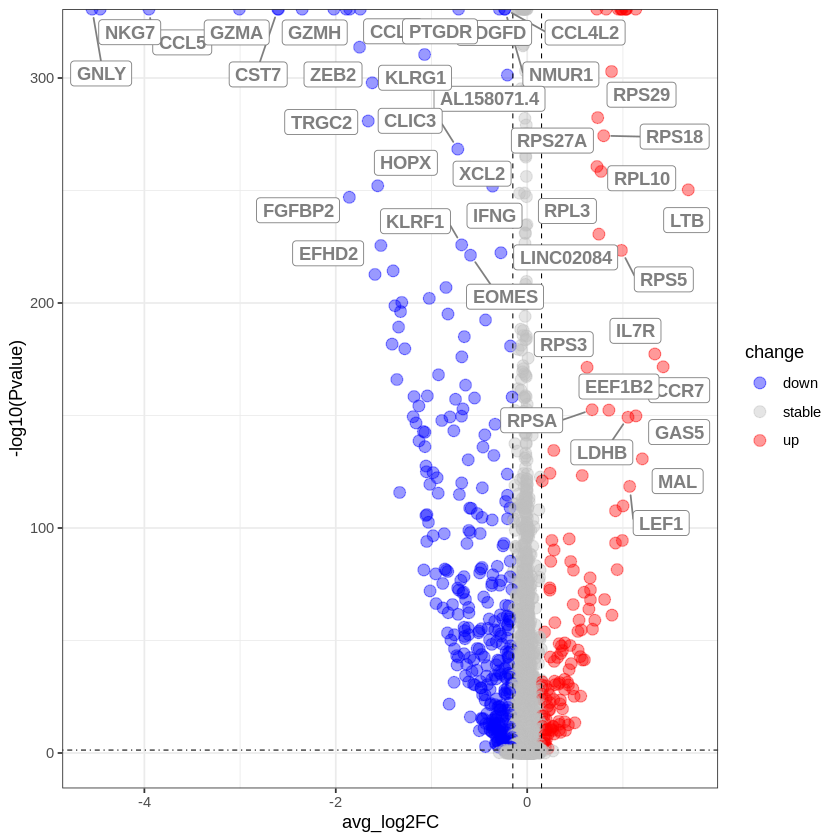

In [12]:
p<-ggplot(degdf, aes(avg_log2FC,  -log10(p_val_adj))) +
    geom_point(alpha=0.4, size=3, aes(color=change)) +
    ylab("-log10(Pvalue)")+
    scale_color_manual(values=c("blue", "grey","red"))+
    geom_hline(yintercept = -log10(P.Value_t),lty=4,col="black",lwd=0.3) +
    geom_vline(xintercept = 0.15,lty=2,col="black",lwd=0.3)+
    geom_vline(xintercept = -0.15,lty=2,col="black",lwd=0.3)+
    geom_label_repel(aes(label=sign), fontface="bold", color="grey50", box.padding=unit(0.35, "lines"), point.padding=unit(0.5, "lines"), segment.colour = "grey50")+
    theme_bw()
p

> Each point represents a gene. Stable means no significant change. Gene expression downregulation is very prominent.  
Need to figure out the up/down is with respect to which identity though; note to self

## Get up and down regulated genes

In [13]:
gene_up=rownames(deg[deg$avg_log2FC > 0.15,])
gene_down=rownames(deg[deg$avg_log2FC < -0.15,])

## Convert gene name to ENTREZID for GO and KEGG

In [14]:
library(org.Hs.eg.db)
gene_up=as.character(na.omit(AnnotationDbi::select(org.Hs.eg.db,
                                                keys = gene_up,
                                                columns = 'ENTREZID',
                                                keytype = 'SYMBOL')[,2]))
gene_down=as.character(na.omit(AnnotationDbi::select(org.Hs.eg.db,
                                                  keys = gene_down,
                                                  columns = 'ENTREZID',
                                                  keytype = 'SYMBOL')[,2]))

head(gene_up)
# head(gene_down)

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



[1] "1915" "6137" "6156" "6161" "6164" "6228"

# Functional Study

## GO Analysis

### Gene function

In [15]:
##CC表示细胞组分，MF表示分子功能，BP表示生物学过程，ALL表示同时富集三种过程。

geneset <- gene_up # Only studying up-regulated genes
deg_type <- "up"

# ego_ALL <- enrichGO(gene = geneset,
#                 OrgDb=org.Hs.eg.db,
#                 keyType = "ENTREZID",
#                 ont = "ALL",
#                 pAdjustMethod = "BH",
#                 minGSSize = 1,
#                 pvalueCutoff = 0.05,
#                 qvalueCutoff = 0.05,
#                 readable = TRUE)

ego_CC <- enrichGO(gene = geneset,
                OrgDb=org.Hs.eg.db,
                keyType = "ENTREZID",
                ont = "CC",
                pAdjustMethod = "BH",
                minGSSize = 1,
                pvalueCutoff = 0.05,
                qvalueCutoff = 0.05,
                readable = TRUE)
ego_BP <- enrichGO(gene = geneset,
                OrgDb=org.Hs.eg.db,
                keyType = "ENTREZID",
                ont = "BP",
                pAdjustMethod = "BH",
                minGSSize = 1,
                pvalueCutoff = 0.05,
                qvalueCutoff = 0.05,
                readable = TRUE)

ego_MF <- enrichGO(gene = geneset,
                 OrgDb=org.Hs.eg.db,
                 keyType = "ENTREZID",
                 ont = "MF",
                 pAdjustMethod = "BH",
                 minGSSize = 1,
                 pvalueCutoff = 0.05,
                 qvalueCutoff = 0.05,
                 readable = TRUE)

head(ego_MF)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0003735,GO:0003735,structural constituent of ribosome,18/123,182/18368,2.571689e-16,9.129496e-14,6.875884e-14,RPL13/RPL30/RPL32/RPL34/RPS23/RPS27/RPS6/RPS8/RPS12/RPS29/RPS18/RPS27A/RPL10/RPL3/RPS5/RPS3/RPSA/RPS19,18
GO:0001217,GO:0001217,DNA-binding transcription repressor activity,9/123,313/18368,2.598144e-04,3.803052e-02,2.864271e-02,BACH2/LEF1/TCF7/MYC/FOXP1/MAX/SATB1/ZBTB20/ZEB1,9
GO:0032813,GO:0032813,tumor necrosis factor receptor superfamily binding,4/123,49/18368,3.213847e-04,3.803052e-02,2.864271e-02,LTB/BEX3/CD40LG/TNFSF10,4
GO:0097100,GO:0097100,supercoiled DNA binding,2/123,5/18368,4.389678e-04,3.895839e-02,2.934153e-02,RPS3/PSIP1,2


> Nice table! Perfect demonstration of the importance of visualization...

### Visualize

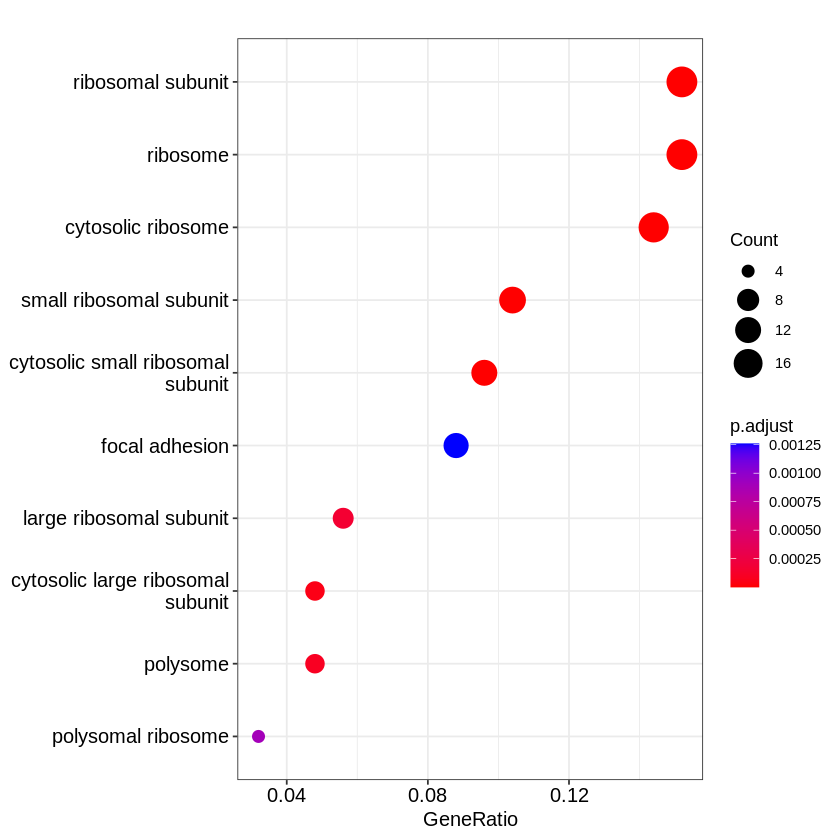

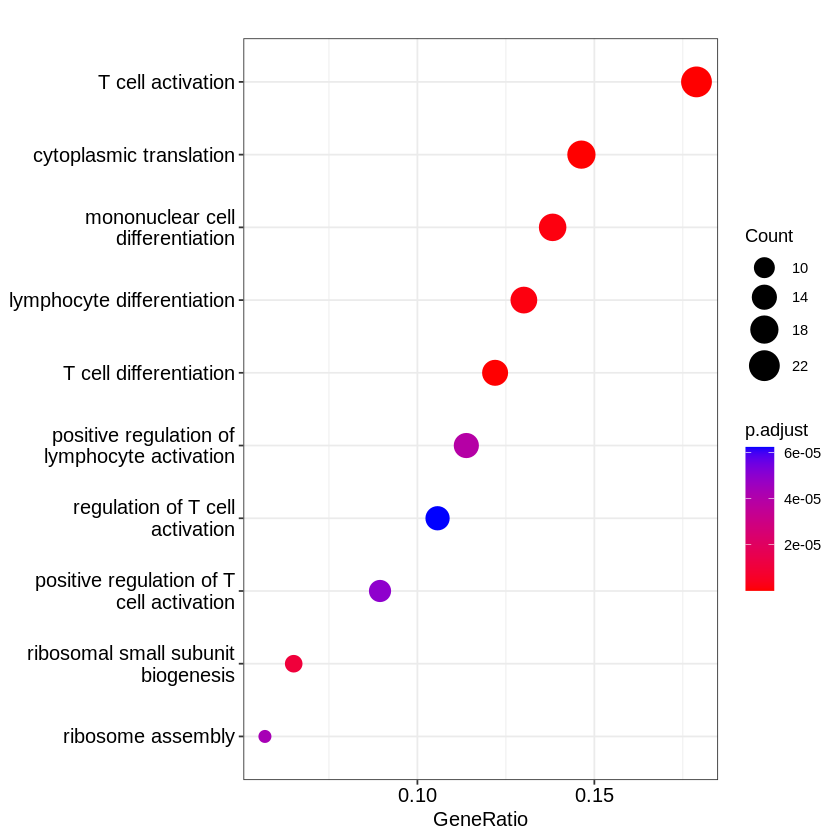

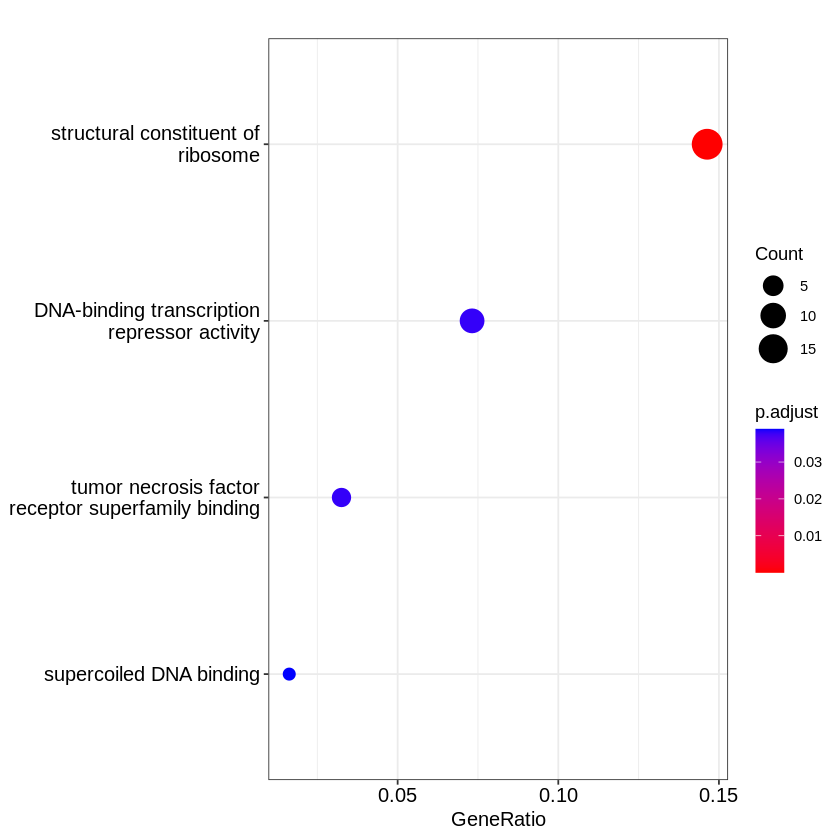

In [17]:
p1 <-dotplot(ego_CC)
p1
p2 <- dotplot(ego_BP)
p2
p3 <- dotplot(ego_MF)
p3

> Larger size means higher count; Red means lower p value  

### GO Term Enrichment

Warning message:
“Removed 6 rows containing missing values (position_stack).”


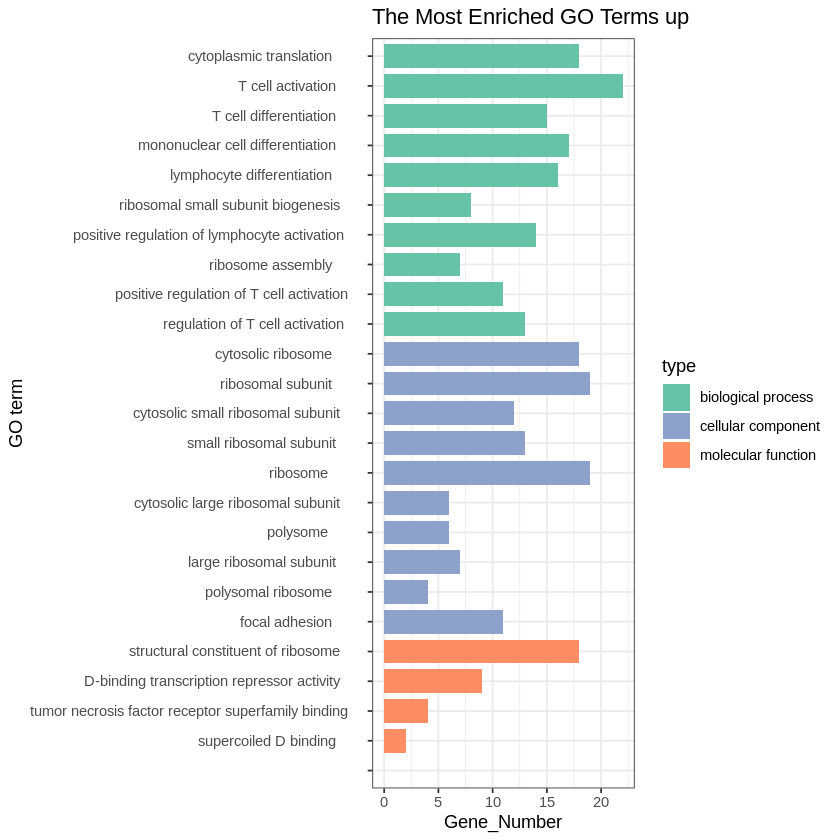

In [18]:
# GO term 柱形图
display_number = c(10,10,10)
ego_result_BP <- as.data.frame(ego_BP)[1:display_number[1], ]
ego_result_CC <- as.data.frame(ego_CC)[1:display_number[2], ]
ego_result_MF <- as.data.frame(ego_MF)[1:display_number[3], ]
              
##将以上我们摘取的部分通路重新组合成数据框
go_enrich_df <- data.frame(
ID=c(ego_result_BP$ID, ego_result_CC$ID, ego_result_MF$ID), Description=c(ego_result_BP$Description,ego_result_CC$Description,ego_result_MF$Description),
GeneNumber=c(ego_result_BP$Count, ego_result_CC$Count, ego_result_MF$Count),
type=factor(c(rep("biological process", display_number[1]), 
              rep("cellular component", display_number[2]),
              rep("molecular function", display_number[3])), 
              levels=c("biological process", "cellular component","molecular function" )))
    
##通路的名字太长，选取通路的前10个单词作为通路的名字
for(i in 1:nrow(go_enrich_df)){
  description_splite=strsplit(go_enrich_df$Description[i],split = " ")
  description_collapse=paste(description_splite[[1]][1:10],collapse = " ") 
  go_enrich_df$Description[i]=description_collapse
  go_enrich_df$Description=gsub(pattern = "NA","",go_enrich_df$Description)
}
    
##绘制GO柱状图
go_enrich_df$type_order=factor(rev(as.integer(rownames(go_enrich_df))),labels=rev(go_enrich_df$Description))
COLS <- c("#66C3A5", "#8DA1CB", "#FD8D62")
p2<- ggplot(data=go_enrich_df, aes(x=type_order,y=GeneNumber, fill=type)) + 
  geom_bar(stat="identity", width=0.8) + 
  scale_fill_manual(values = COLS) + 
  coord_flip() + 
  xlab("GO term") + 
  ylab("Gene_Number") + 
  labs(title = paste0("The Most Enriched GO Terms ",deg_type))+
  theme_bw()
p2

> Better than looking at the size of spheres

## KEGG

### Important to set the download option

In [20]:
# 设置下载方法
R.utils::setOption("clusterProfiler.download.method",'auto')

### KEGG Enrichment

In [21]:
kk <- enrichKEGG(gene = geneset,keyType = "kegg",organism= "hsa", qvalueCutoff = 0.05, pvalueCutoff=0.05)
head(kk)

Reading KEGG annotation online:


Reading KEGG annotation online:




,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
hsa03010,hsa03010,Ribosome,18/74,158/8163,1.566618e-15,2.663251e-13,2.259229e-13,6137/6156/6161/6164/6228/6232/6194/6202/6206/6235/6222/6233/6134/6122/6193/6188/3921/6223,18
hsa05171,hsa05171,Coronavirus disease - COVID-19,19/74,232/8163,1.067154e-13,9.070811e-12,7.694744e-12,6137/6156/6161/6164/6228/6232/6194/6202/6206/6235/6222/6233/6134/6122/6193/6188/3921/6223/3572,19
hsa05222,hsa05222,Small cell lung cancer,6/74,92/8163,1.740452e-04,9.862564e-03,8.366385e-03,4609/2272/3655/4149/596/330,6
hsa05132,hsa05132,Salmonella infection,9/74,249/8163,3.871253e-04,1.645282e-02,1.395688e-02,6188/51176/6932/4609/596/9648/8743/330/399,9
hsa04060,hsa04060,Cytokine-cytokine receptor interaction,9/74,295/8163,1.305402e-03,4.373973e-02,3.710429e-02,4050/3575/1236/3572/939/959/7293/8743/7852,9
hsa05202,hsa05202,Transcriptional misregulation in cancer,7/74,193/8163,1.748718e-03,4.373973e-02,3.710429e-02,3480/4609/4149/64919/330/4300/6935,7


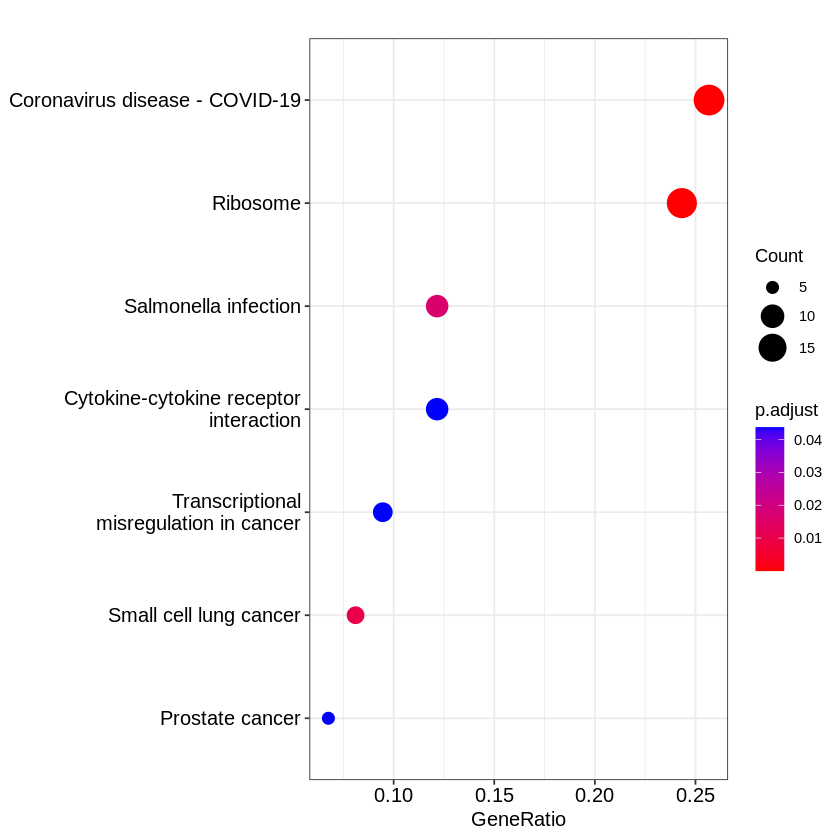

In [22]:
# KEGG dotplot
p<-dotplot(kk)
p

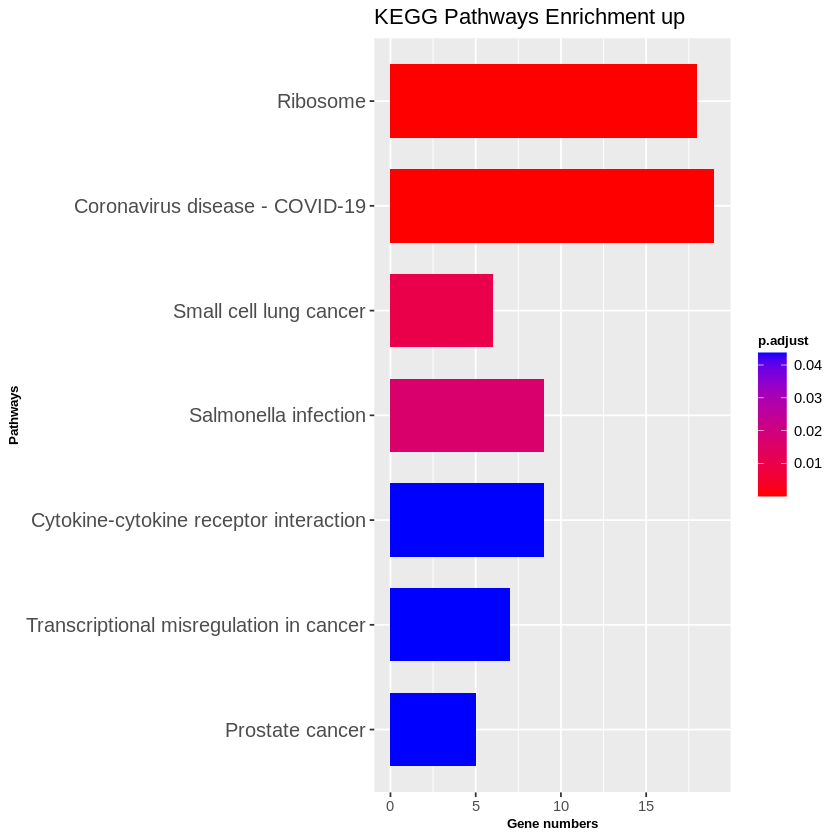

In [25]:
##KEGG 柱状图
hh <- as.data.frame(kk)

# 转换rownames为数字
rownames(hh) <- 1:nrow(hh)
hh$order=factor(rev(as.integer(rownames(hh))),labels = rev(hh$Description))

p4 <- ggplot(hh,aes(y=order,x=Count,fill=p.adjust))+
  geom_bar(stat = "identity",width=0.7)+
  scale_fill_gradient(low = "red",high ="blue" )+
  labs(title = paste0("KEGG Pathways Enrichment ",deg_type),
       x = "Gene numbers", 
       y = "Pathways")+
  theme(axis.title.x = element_text(face = "bold",size = 8),
       axis.title.y = element_text(face = "bold",size = 8),
       legend.title = element_text(face = "bold",size = 8),
       axis.text.y = element_text(size=12))
  #theme_bw()
p4

# Trajectory Inference

> There is another RNA velocity study that infers on rate of change of gene expression, but here we are just doing trajectory inference

## Load packages

In [4]:
library(monocle3) # Based on PAGA algorithm
library(SeuratWrappers) # 可将seurat对象转换为其他对象格式
library(dplyr)


Attaching package: ‘monocle3’


The following objects are masked from ‘package:Biobase’:

    exprs, fData, fData<-, pData, pData<-



Attaching package: ‘dplyr’


The following object is masked from ‘package:AnnotationDbi’:

    select


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from

## Choose clusters to analyze

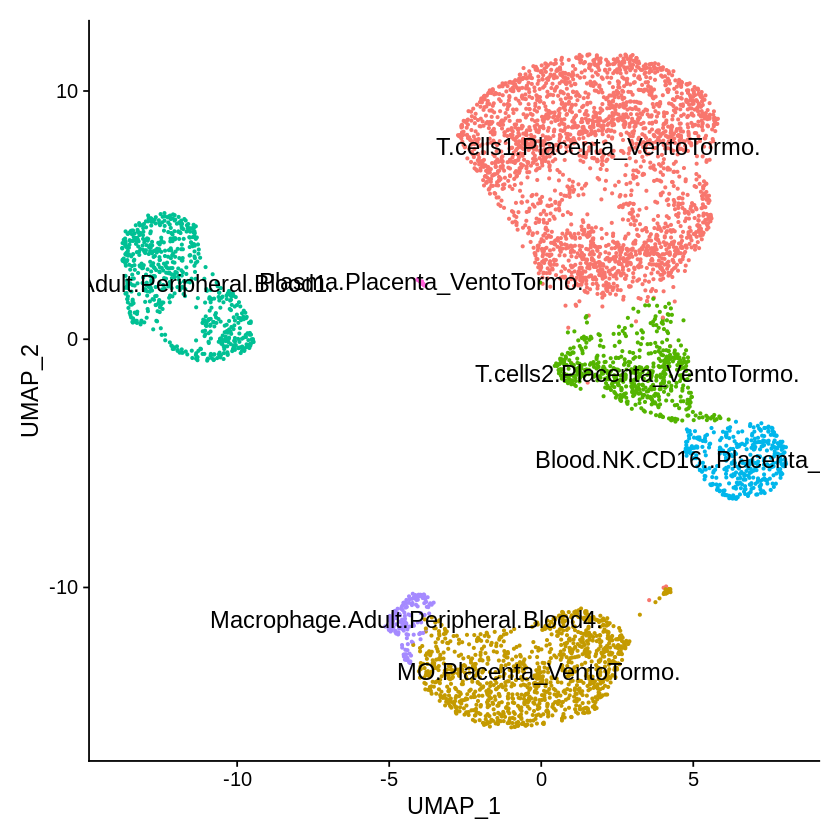

In [5]:
DimPlot(su3_1, reduction = "umap", label = TRUE, label.size = 5,pt.size = 0.5)+ NoLegend()

> This figure again

In [9]:
labels

[1] "T.cells1.Placenta_VentoTormo."       "MO.Placenta_VentoTormo."            
[3] "T.cells2.Placenta_VentoTormo."       "B.cell.Adult.Peripheral.Blood1."    
[5] "Blood.NK.CD16..Placenta_VentoTormo." "Macrophage.Adult.Peripheral.Blood4."
[7] "Plasma.Placenta_VentoTormo."

In [27]:
# Do T cell cluster
B.obj <- subset(su3_1, idents = c("T.cells1.Placenta_VentoTormo.",
                                  "T.cells2.Placenta_VentoTormo.",
                                  "Blood.NK.CD16..Placenta_VentoTormo."))
B.obj
table(B.obj@active.ident)

An object of class Seurat 
56767 features across 3502 samples within 3 assays 
Active assay: integrated (2000 features, 2000 variable features)
 2 other assays present: RNA, SCT
 2 dimensional reductions calculated: pca, umap


      T.cells1.Placenta_VentoTormo.       T.cells2.Placenta_VentoTormo. 
                               2530                                 588 
Blood.NK.CD16..Placenta_VentoTormo. 
                                384 

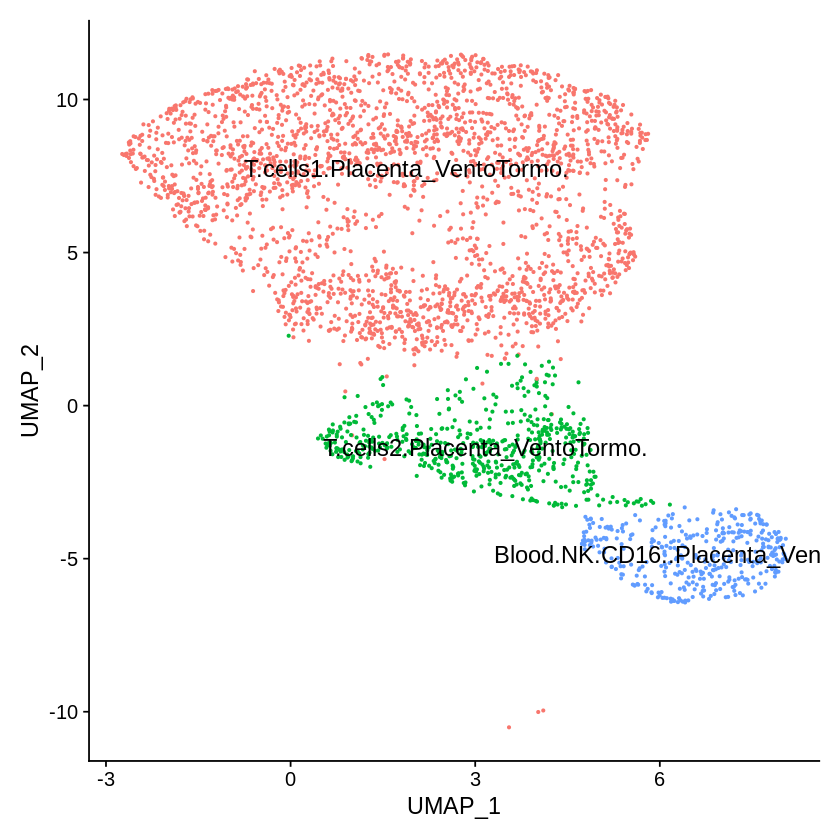

In [28]:
DimPlot(B.obj, reduction = "umap", label = TRUE, label.size = 5,pt.size = 0.5)+ NoLegend()

## Data processing

### SCTransform

In [29]:
B.obj <- SCTransform(B.obj)

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 16895 by 3502

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 3502 cells



  |======================================================================| 100%


Found 59 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 16895 genes



  |======================================================================| 100%


Computing corrected count matrix for 16895 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 43.61409 secs

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT



### PCA

In [30]:
B.obj <- RunPCA(B.obj,
                rev.pca = TRUE,
                assay = "SCT",
                verbose = "FALSE")

In [31]:
makeScree <- function(seuratObject,numPCs){
    result <- seuratObject@reductions
    sdv <- result$pca@stdev[1:numPCs]
    names <- attributes(result$pca@cell.embeddings)[[2]][2] %>% unlist
    names <- names[1:numPCs]
    
    scree <- as.data.frame(list(names,sdv^2/sum(sdv^2)))
    colnames(scree) <- c("PC","Percent")
    scree$PC <- factor(scree$PC,levels = scree$PC)

    ggplot(scree, aes(x = PC,y = Percent,group=1)) +
    geom_line(color="grey") +
    geom_point() +
    ggtitle("Scree Plot") +
    xlab("Principal Components") +
    ylab("Percent Variance Explained") +
    theme_minimal()
    }

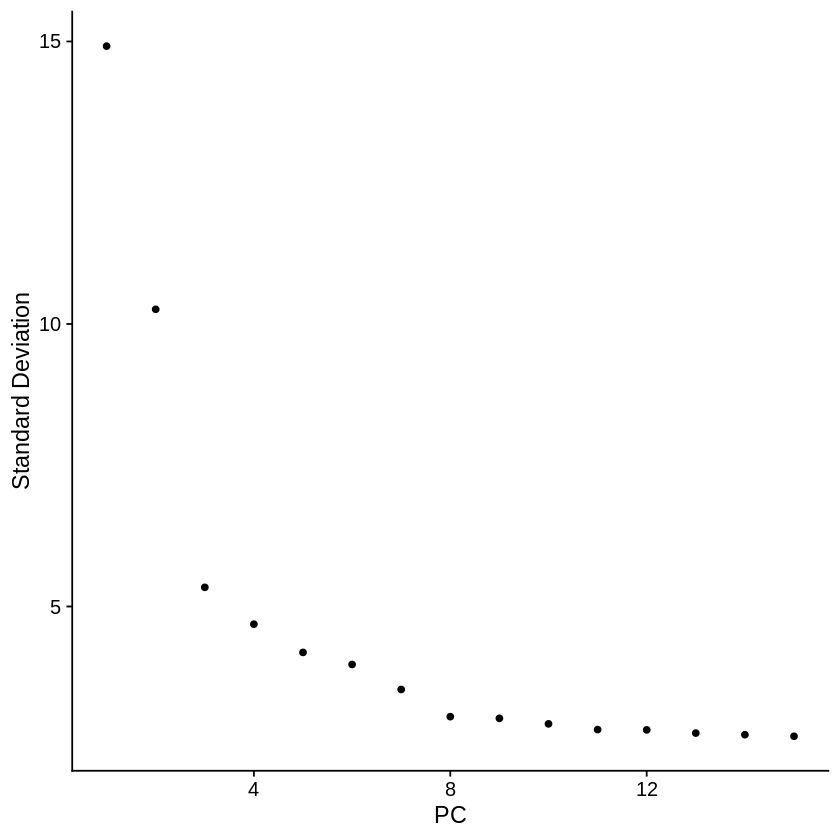

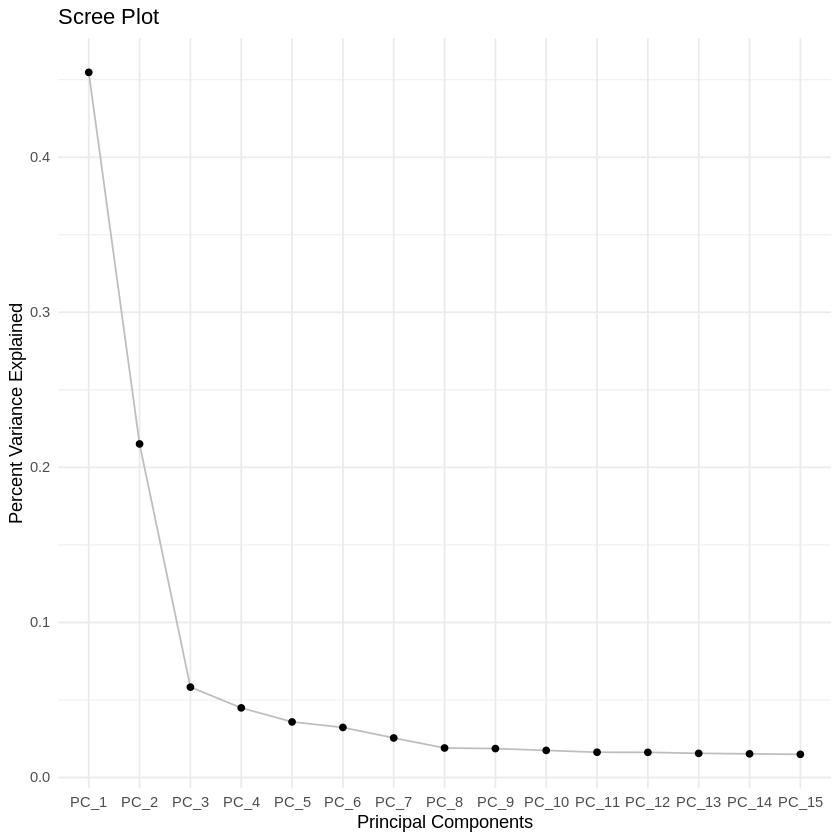

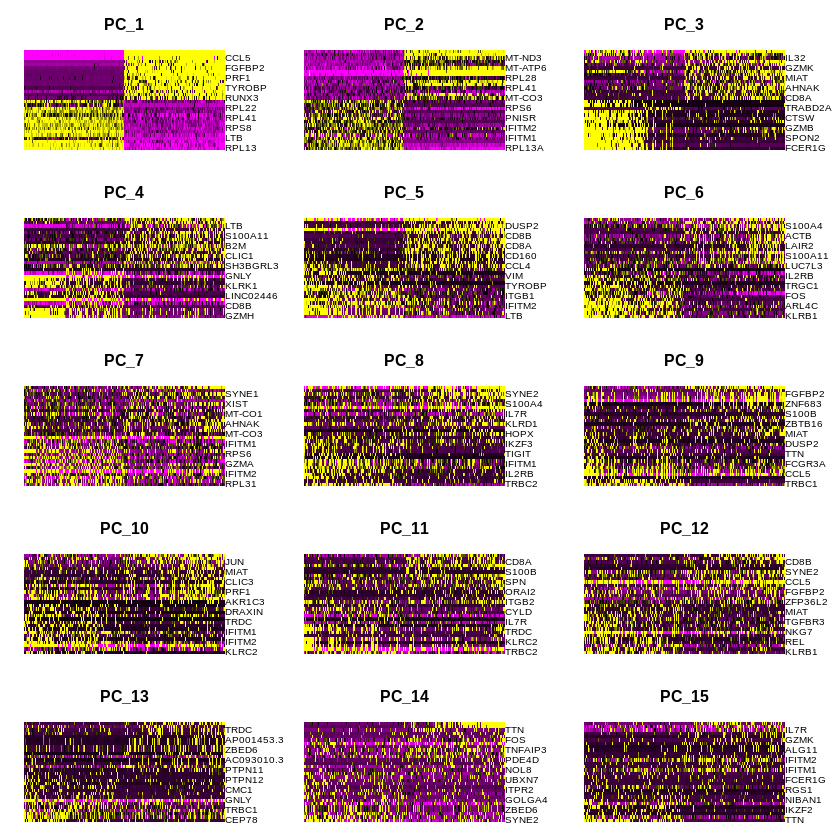

In [32]:
ndims <- 15

ElbowPlot(B.obj, ndims= ndims)

makeScree(B.obj, numPCs=ndims)

DimHeatmap(B.obj, dims = 1:ndims, cells = 500, balanced = TRUE)

> Keeping 8 PCs seem reasonable

### UMAP

In [33]:
B.obj <- FindNeighbors(B.obj, dims = 1:8)

Computing nearest neighbor graph

Computing SNN



In [34]:
B.obj <- FindClusters(B.obj, resolution=0.9)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3502
Number of edges: 112117

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8392
Number of communities: 12
Elapsed time: 0 seconds


In [35]:
B.obj <- RunUMAP(B.obj, dims = 1:8, n.neighbors = 50)

15:40:11 UMAP embedding parameters a = 0.9922 b = 1.112

15:40:11 Read 3502 rows and found 8 numeric columns

15:40:11 Using Annoy for neighbor search, n_neighbors = 50

15:40:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:40:12 Writing NN index file to temp file /tmp/RtmpKDZIDM/file9916d196bb

15:40:12 Searching Annoy index using 1 thread, search_k = 5000

15:40:14 Annoy recall = 100%

15:40:14 Commencing smooth kNN distance calibration using 1 thread

15:40:16 Initializing from normalized Laplacian + noise

15:40:16 Commencing optimization for 500 epochs, with 213110 positive edges

15:40:21 Optimization finished



In [36]:
table(B.obj@active.ident)


  0   1   2   3   4   5   6   7   8   9  10  11 
524 394 391 383 363 361 345 240 186 129  97  89 

> The cells are re-clustered

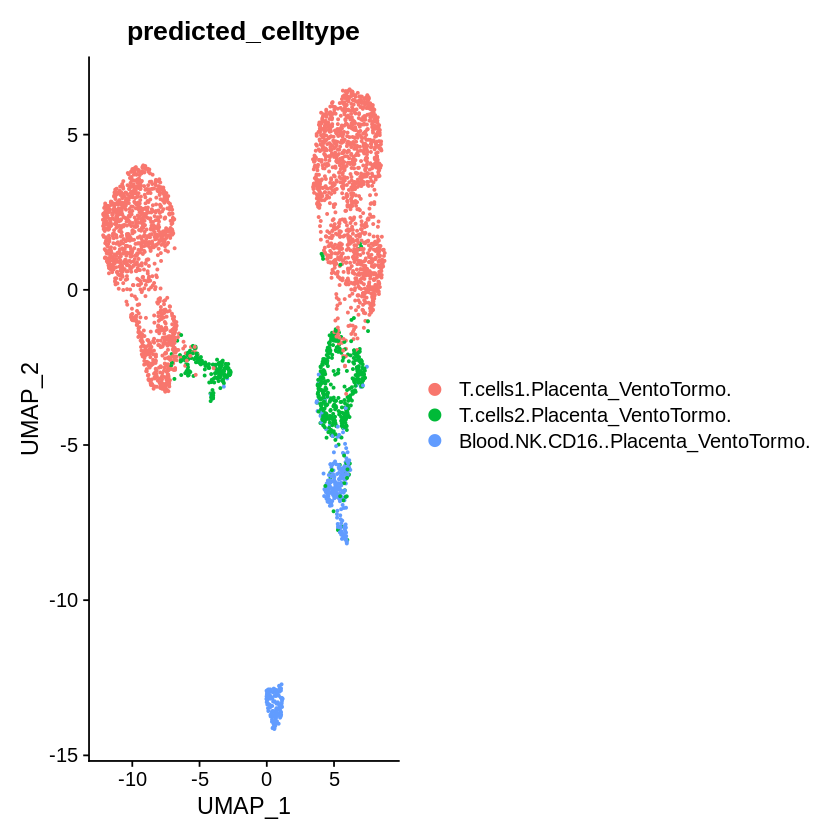

In [37]:
DimPlot(B.obj,group.by = "predicted_celltype")

## Convert to cds object

In [38]:
cds <- as.cell_data_set(B.obj)
cds <- estimate_size_factors(cds)
cds <- cluster_cells(cds = cds, reduction_method = "UMAP")

Warning message:
“Monocle 3 trajectories require cluster partitions, which Seurat does not calculate. Please run 'cluster_cells' on your cell_data_set object”


## Compute trajectories

  |======================================================================| 100%


Warning message in igraph::graph.dfs(stree_ori, root = root_cell, neimode = "all", :
“Argument `neimode' is deprecated; use `mode' instead”


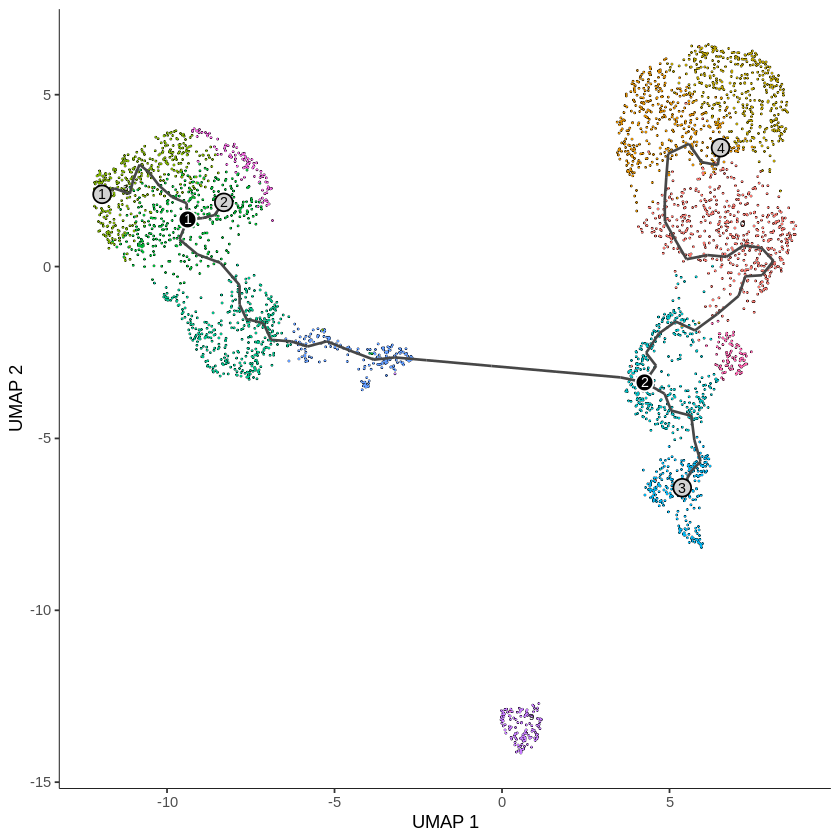

In [39]:
cds <- learn_graph(cds, use_partition = TRUE)
plot_cells(
    cds, 
    color_cells_by = "seurat_clusters", 
    label_groups_by_cluster=TRUE,
    label_leaves=TRUE, 
    label_branch_points=TRUE,
    graph_label_size=3
)

In [43]:
?learn_graph

learn_graph {monocle3},R Documentation
cds,the cell_data_set upon which to perform this operation
use_partition,"logical parameter that determines whether to use partitions calculated during cluster_cells and therefore to learn disjoint graph in each partition. When use_partition = FALSE, a single graph is learned across all partitions. Default is TRUE."
close_loop,logical parameter that determines whether or not to perform an additional run of loop closing after estimating the principal graphs to identify potential loop structure in the data space. Default is TRUE.
learn_graph_control,NULL or a list of control parameters to be passed to the reversed graph embedding function. Default is NULL. A list of potential control parameters is provided in details.
verbose,Whether to emit verbose output during graph learning.


> Black nodes mean a split in trajectories.

## Set root cells

> Manually set beginning of development; out of Africa!

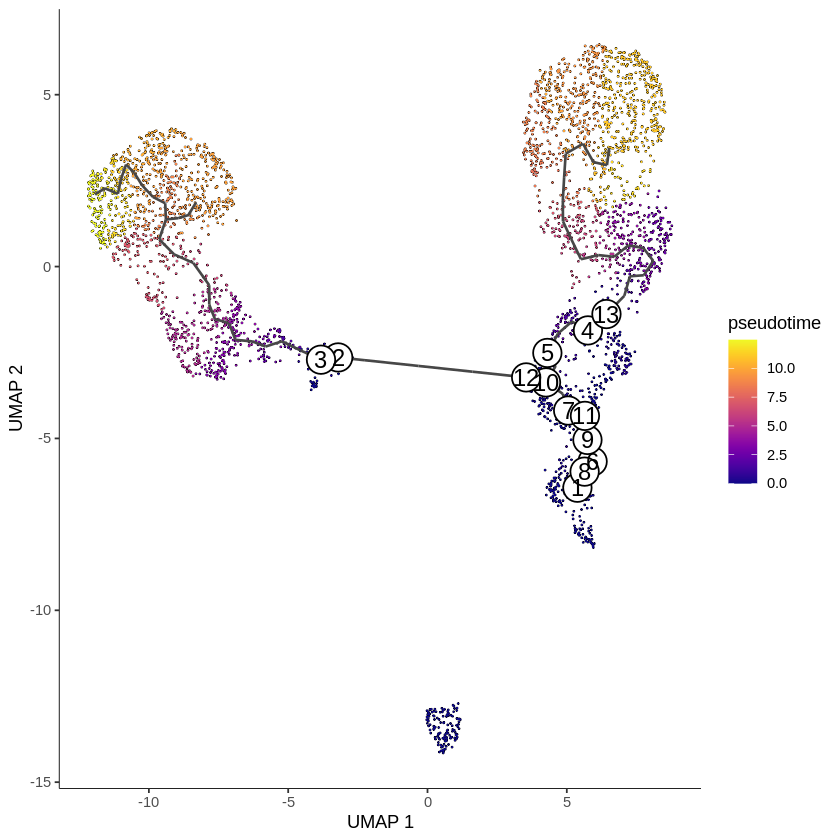

In [40]:
rootcell <- rownames(B.obj@meta.data[which(B.obj$predicted_celltype 
                                           == "Blood.NK.CD16..Placenta_VentoTormo."),])
cds <- order_cells(cds, reduction_method = "UMAP", root_cells=rootcell)


plot_cells(
  cds = cds,
  color_cells_by = "pseudotime",
  label_cell_groups = FALSE,
  label_branch_points=FALSE,
  label_leaves = FALSE,
  graph_label_size = 5
)

> Pseudotime simulates development time; dark color means early in development; light means later in development

## DEG analysis

### Analyze

In [41]:
# 进行差异分析
subset_pr_test_res <- graph_test(cds, neighbor_graph="principal_graph", cores=4)  # neighbor_graph default knn
head(subset_pr_test_res)

Registered S3 method overwritten by 'spdep':
  method   from
  plot.mst ape 



  |=======================================================| 100%, Elapsed 01:54


,status,p_value,morans_test_statistic,morans_I,q_value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
AL627309.1,OK,6.548307e-01,-0.3983956,-0.002062371,7.611198e-01
AL627309.5,OK,6.766963e-02,1.4933742,0.006825923,1.413073e-01
LINC01409,OK,8.619132e-06,4.2979531,0.020321175,3.868763e-05
LINC01128,OK,1.658049e-01,0.9708765,0.004382236,2.925307e-01
LINC00115,OK,3.608565e-01,0.3561703,0.001405296,5.299149e-01
FAM41C,OK,3.231463e-01,0.4589185,0.001886292,4.884199e-01


> Morans: higher means similar expression levels

### Choose genes based on Morans value, and display expression changes among clusters

[1] "GNLY"        "RPS10-NUDT3" "GZMH"        "NKG7"

Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Transformation introduced infinite values in continuous y-axis”
Warning message:
“Removed 8420 rows containing missing values (geom_point).”


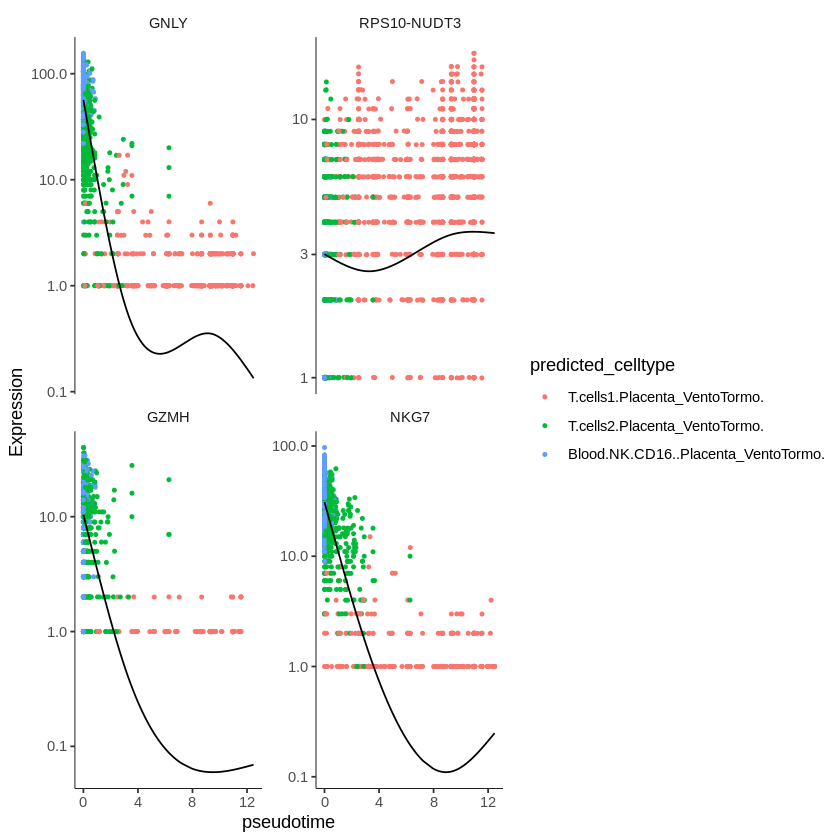

In [42]:
topgene <- subset_pr_test_res %>% top_n(n=4, morans_I) %>% row.names() %>% as.character()
topgene

plot_genes_in_pseudotime(cds[topgene,], color_cells_by="predicted_celltype", ncol=2,
                              label_by_short_name = F)

### Display gene expression patterns of the top genes on UMAP

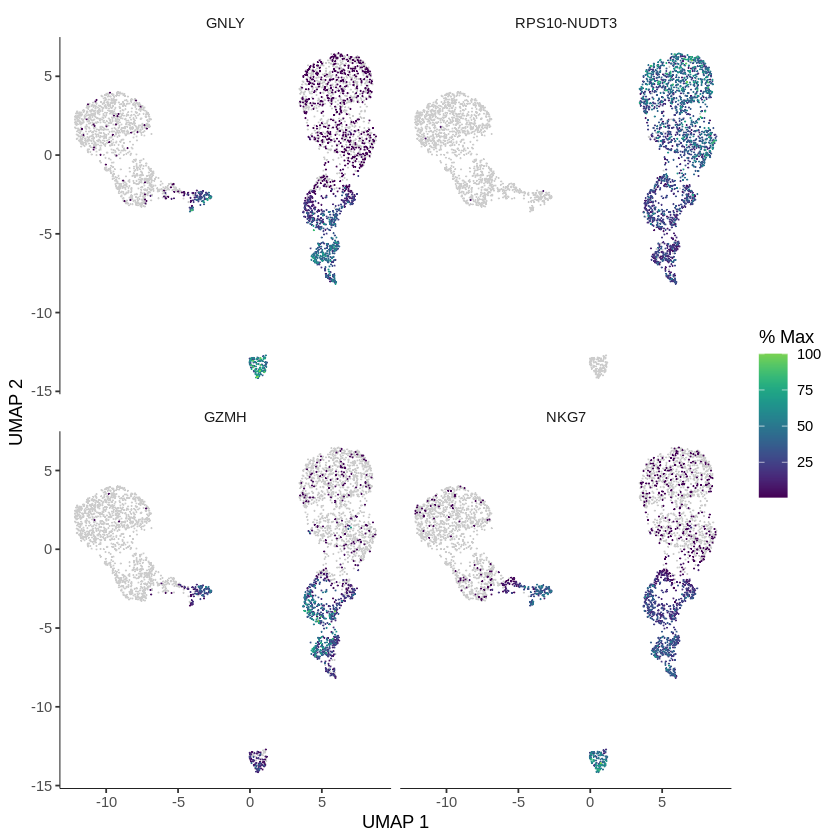

In [78]:
rowData(cds)$gene_name <- rownames(cds)
rowData(cds)$gene_short_name <- rowData(cds)$gene_name

plot_cells(cds, genes=topgene, show_trajectory_graph=FALSE,
          label_cell_groups=FALSE,  label_leaves=FALSE)

> Good show of different pattern changes

Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.



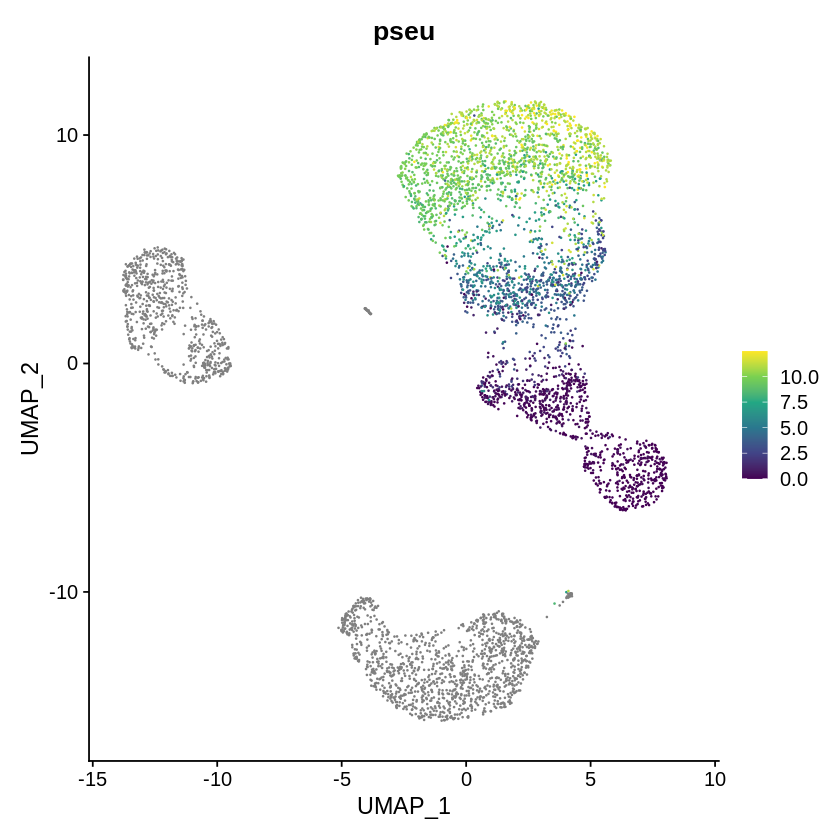

In [77]:
# pseudotime结果保存与Seurat object Metadata中
su3_1 <- AddMetaData(
  object = su3_1,
  metadata = cds@principal_graph_aux@listData$UMAP$pseudotime,
  col.name = "pseu"
)

FeaturePlot(su3_1, c("pseu"), pt.size = 0.1) & scale_color_viridis_c()

> Displays on in clusters with pseudotime inference; Goes from bottom to top

# Cell Communication Analysis

>cellChatDB: database for cell communication analysis; contains info on cell communication ligand and receptors

## Load package

In [160]:
library(CellChat)

In [ ]:
su3_1 <- readRDS("./hw1.rds")

## Load data

In [178]:
# Get data from SCT assay

data.input <- GetAssayData(su3_1, assay = "SCT", slot = "data") # normalized data matrix
labels <- Idents(su3_1)
meta <- data.frame(group = labels, row.names = names(labels)) 

head(meta)

,group
,<fct>
ACGTAGTTCTCGGGAC-1,B.cell.Adult.Peripheral.Blood1.
GTCCCATCACCGTCGA-1,T.cells1.Placenta_VentoTormo.
CGTCAAATCGTCCATC-1,Macrophage.Adult.Peripheral.Blood4.
TGAGACTCACGAGGTA-1,B.cell.Adult.Peripheral.Blood1.
TCCGATCTCAAGTAAG-1,B.cell.Adult.Peripheral.Blood1.
TGCAGATGTCTGGTTA-1,Blood.NK.CD16..Placenta_VentoTormo.


In [179]:
# Make cellChat object
cellchat <- createCellChat(object = data.input)
# Add cell type information
cellchat <- addMeta(cellchat, meta = meta, meta.name = "labels")
cellchat <- setIdent(cellchat, ident.use = "labels")

head(cellchat@idents)

Create a CellChat object from a data matrix



[1] B.cell.Adult.Peripheral.Blood1.     T.cells1.Placenta_VentoTormo.      
[3] Macrophage.Adult.Peripheral.Blood4. B.cell.Adult.Peripheral.Blood1.    
[5] B.cell.Adult.Peripheral.Blood1.     Blood.NK.CD16..Placenta_VentoTormo.
7 Levels: T.cells1.Placenta_VentoTormo. ... Plasma.Placenta_VentoTormo.

## Load database for humans

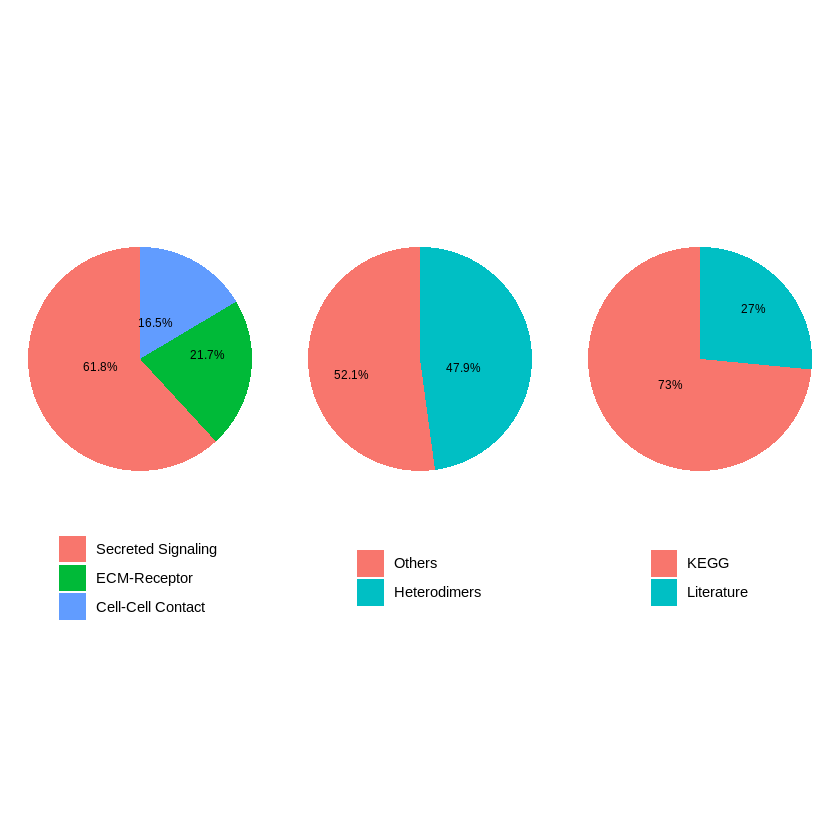

In [180]:
# 导入配受体数据库
CellChatDB <- CellChatDB.human
# 
showDatabaseCategory(CellChatDB)

> Shows database structure

## Choose a database to use

In [181]:
# 选取分泌信号通路进行下游分析
CellChatDB.use <- subsetDB(CellChatDB, search = "Secreted Signaling") 
cellchat@DB <- CellChatDB.use # set the used database in the object
unique(CellChatDB$interaction$annotation)

[1] "Secreted Signaling" "ECM-Receptor"       "Cell-Cell Contact"

## Analysis settings

In [193]:
# 首先在一个细胞群中识别过表达的配体或受体，然后识别其相互作用；
# 可将基因表达数据投射到蛋白-蛋白相互作用(PPI)网络上。

# Subset the cells to save computation cost.
cellchat <- subsetData(cellchat)


In [194]:
dim(cellchat@data.signaling)

[1]  361 5462

> Any input besides features = NULL gives 0 by # of cells

## Analyze communications between over-expressed cells

In [195]:
future::plan("multiprocess", workers = 1) # set num of parallel workers
# 识别过表达基因
cellchat <- identifyOverExpressedGenes(cellchat)
# 识别过表达基因的互作
cellchat <- identifyOverExpressedInteractions(cellchat)

# 通过PPI对基因表达进行smooth
cellchat <- projectData(cellchat, PPI.human)  # 注意如果进行PPI smooth，则进行computeCommunProb计算时，raw.use = FALSE

Warning message:
“Strategy 'multiprocess' is deprecated in future (>= 1.20.0) [2020-10-30]. Instead, explicitly specify either 'multisession' (recommended) or 'multicore'. In the current R session, 'multiprocess' equals 'multicore'.”


> I think due to user restrictions we can only use 1 worker or the system slaps us in the face with error messages

## Infer biological significance of the communications

In [196]:
# CellChat通过给每个相互作用赋一个概率值并进行排列、测试，来推断具有生物意义的细胞通讯。
# 通过置换检验来推断生物意义上的细胞-细胞通信。

# 计算通讯概率
cellchat <- computeCommunProb(cellchat, raw.use = FALSE)  # 默认 raw.use = TRUE

# 对细胞进行过滤
cellchat <- filterCommunication(cellchat, min.cells = 10) 
# If too few cells probably not real communications

# 通过计算的每个配体-受体通信概率来计算信号通路层面的通信概率
# 每个信号通路分别存储在“net”和“netP”槽中
cellchat <- computeCommunProbPathway(cellchat)

## Now get the network of communications

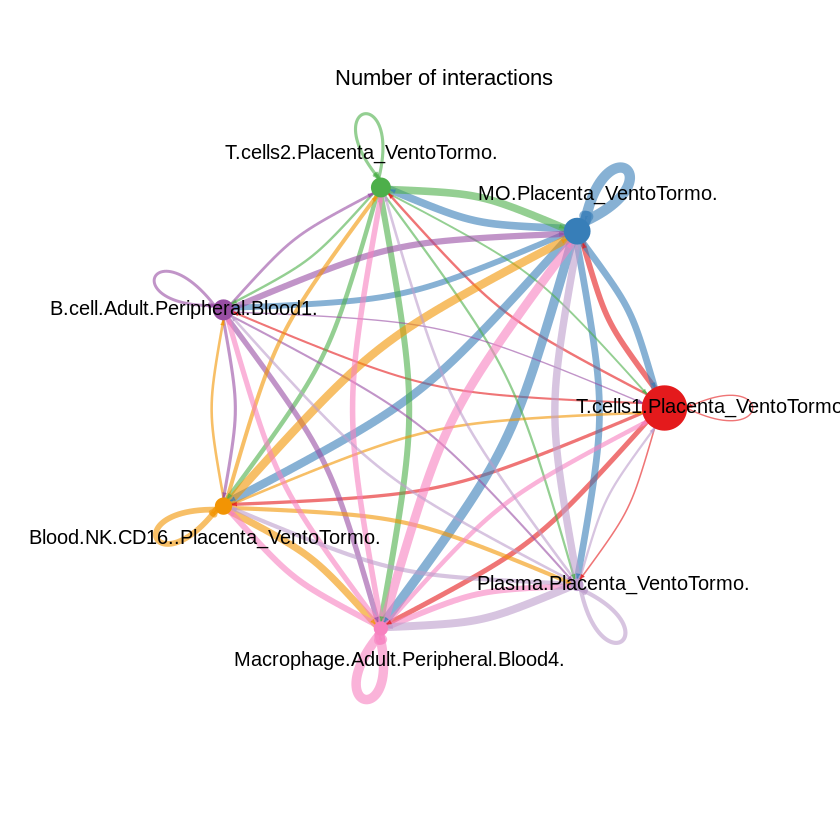

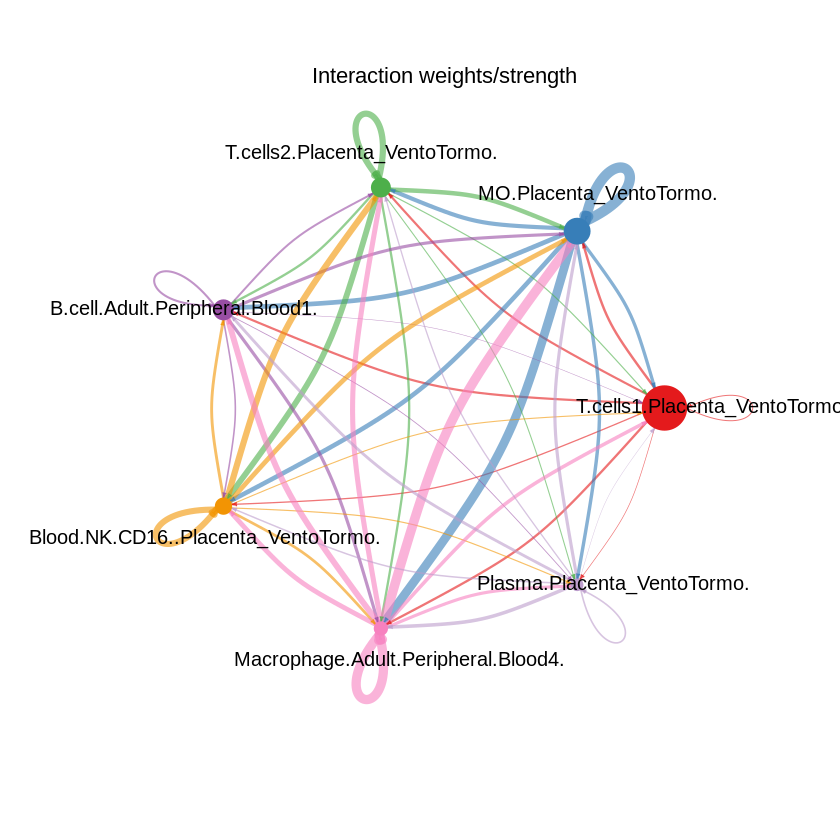

In [197]:
# 计算聚集的细胞通讯网络
cellchat <- aggregateNet(cellchat)

# 统计每个细胞类型数目
groupSize <- as.numeric(table(cellchat@idents))

p1 <- netVisual_circle(cellchat@net$count, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Number of interactions")
p2 <- netVisual_circle(cellchat@net$weight, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Interaction weights/strength")


> Everyone friends with everyone!

## Communications over specific pathways

### Get some pathways to look at

In [206]:
pathways <- cellchat@netP$pathways
pathways

[1] "GALECTIN"   "CCL"        "MIF"        "BAFF"       "LT"        
 [6] "ANNEXIN"    "APRIL"      "IL2"        "TGFb"       "VISFATIN"  
[11] "IL16"       "RESISTIN"   "CX3C"       "GRN"        "TRAIL"     
[16] "BTLA"       "IFN-II"     "PARs"       "IL10"       "LIGHT"     
[21] "CSF"        "COMPLEMENT" "CXCL"       "IL6"        "GAS"       
[26] "VEGF"       "BAG"        "FLT3"       "CD40"       "TWEAK"     
[31] "VEGI"       "IL1"        "FASLG"      "WNT"        "NRG"       
[36] "PDGF"       "FGF"

### Look at cell communication over one pathway

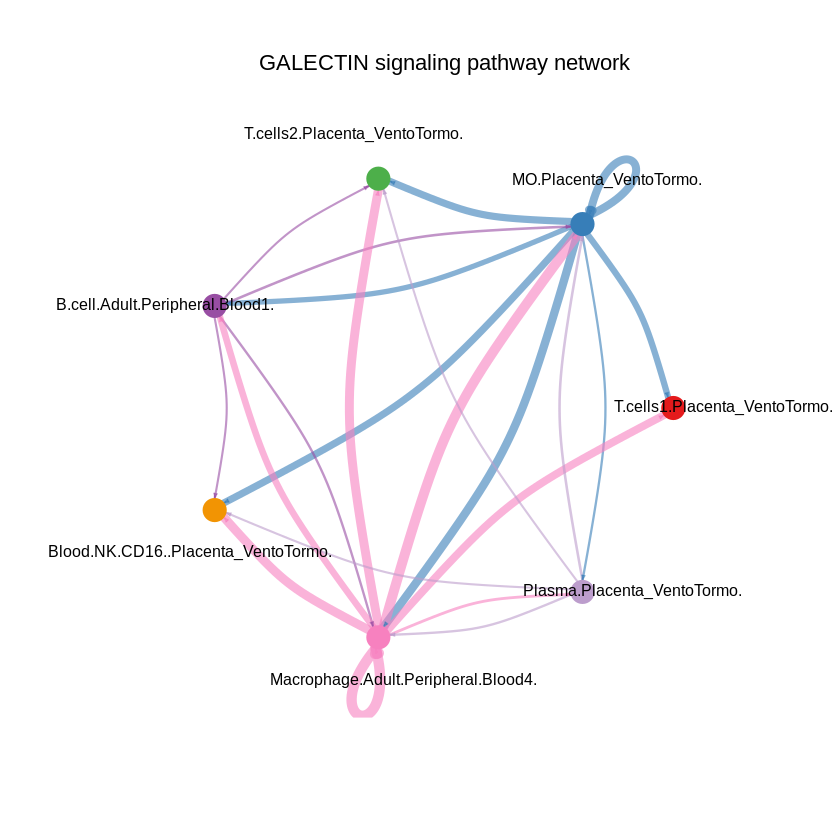

In [208]:
# 细胞通讯信号通路
pathways.show <- "GALECTIN"
# netVisual_aggregate(cellchat, signaling = pathways.show,  vertex.receiver = vertex.receiver, vertex.size = groupSize)   

p3 <- netVisual_aggregate(cellchat, signaling = pathways.show, layout = "circle", vertex.size = groupSize)

> Galectins are implicated in immune activation. So the graph makes sense

Do heatmap based on a single object 




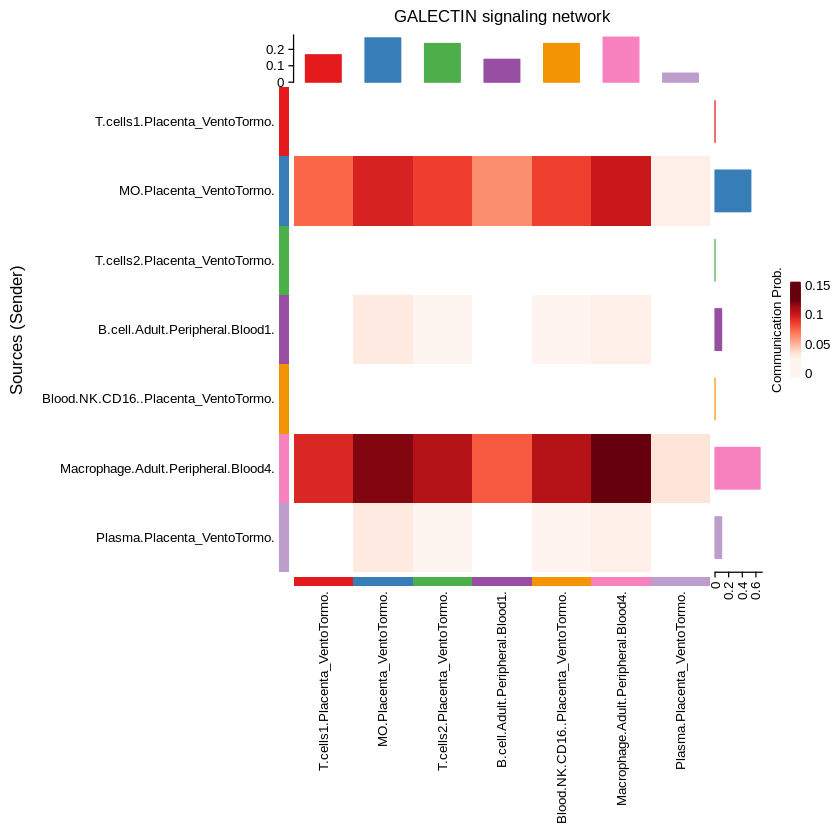

In [216]:
# Heatmap
netVisual_heatmap(cellchat, signaling = pathways.show, color.heatmap = "Reds")
#> Do heatmap based on a single object

> MO_Placenta and Macrophage are really important.

Comparing communications on a single object 




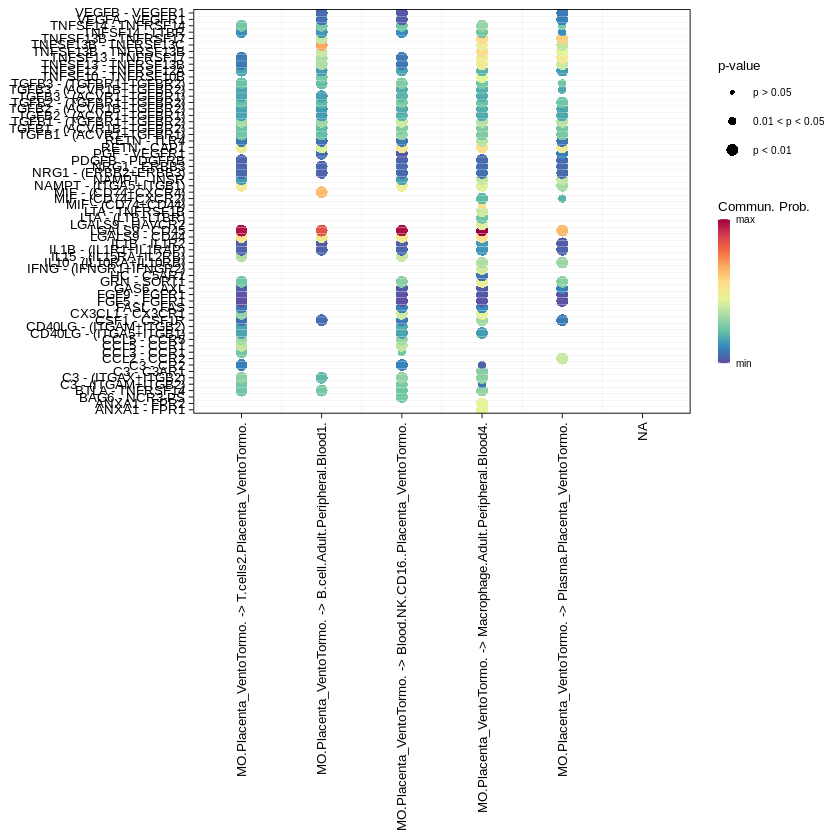

In [221]:
# show all the significant interactions (L-R pairs) from some cell groups (defined by 'sources.use') to other cell groups (defined by 'targets.use')
netVisual_bubble(cellchat, sources.use = 2, targets.use = c(3:10), remove.isolate = FALSE)
#> Comparing communications on a single object

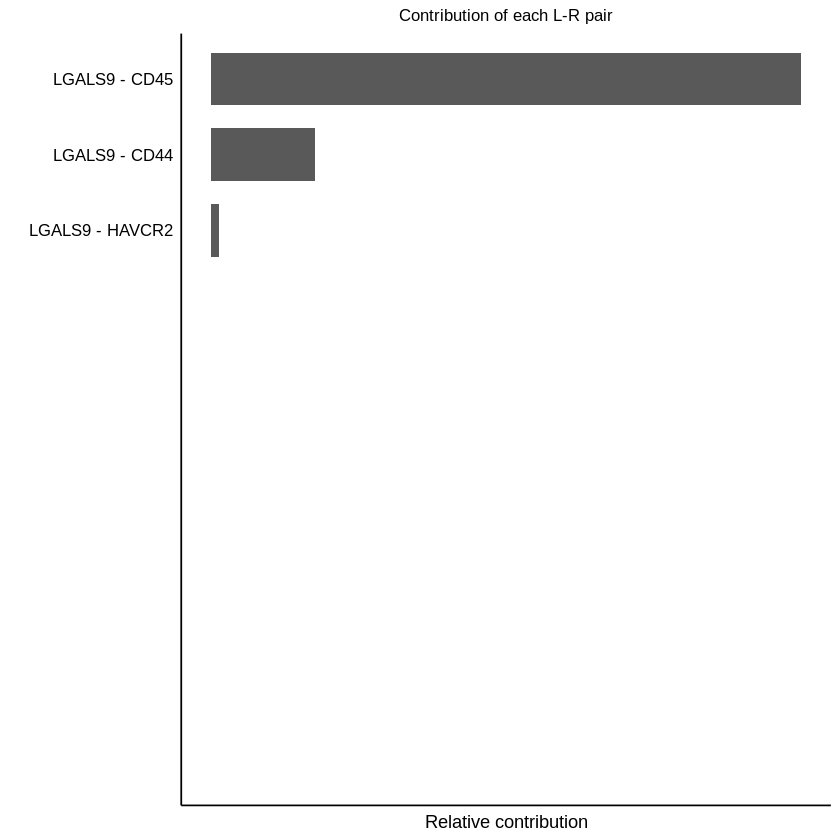

In [222]:
netAnalysis_contribution(cellchat, signaling = pathways.show)

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.



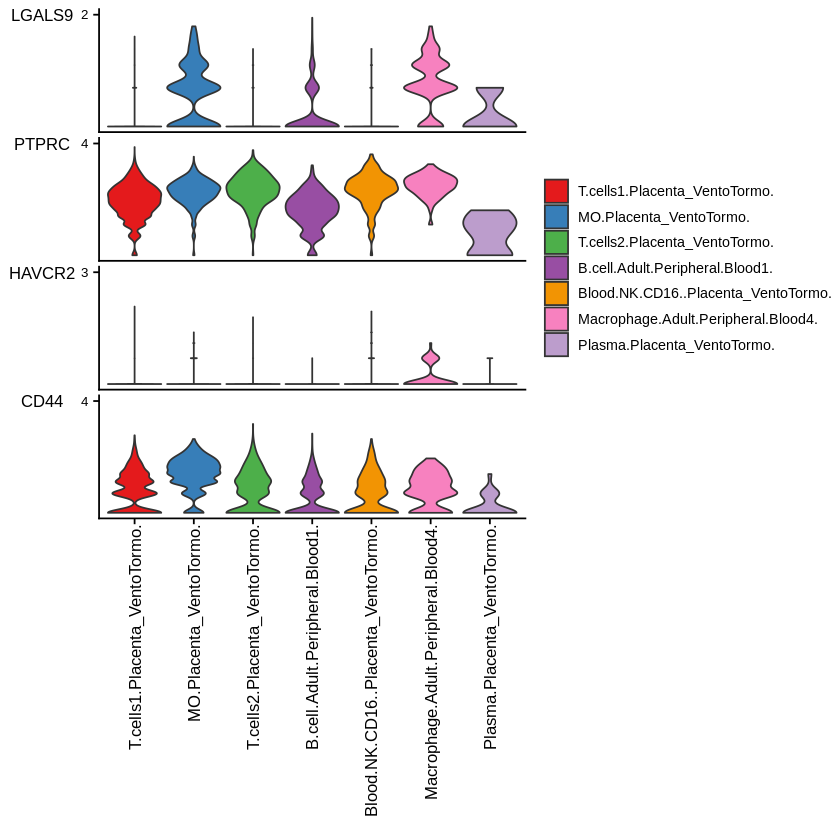

In [223]:
plotGeneExpression(cellchat, signaling = "GALECTIN")